<a href="https://colab.research.google.com/github/ThgShikifujin/pbd/blob/main/memoria_injecao_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando o experimento...
1. Estruturando os dados (Mock Data)...
2. Inicializando o banco de dados...
3. Executando e aferindo as consultas de agregação...

--- TABELA DE RESULTADOS FINAIS ---
Função de Agregação  Tempo de Execução (ms)
              COUNT                859.1235
                SUM               1785.5127
                AVG               1294.1601
                MAX                951.2870
                MIN                689.5876

4. Gerando e exportando os gráficos...


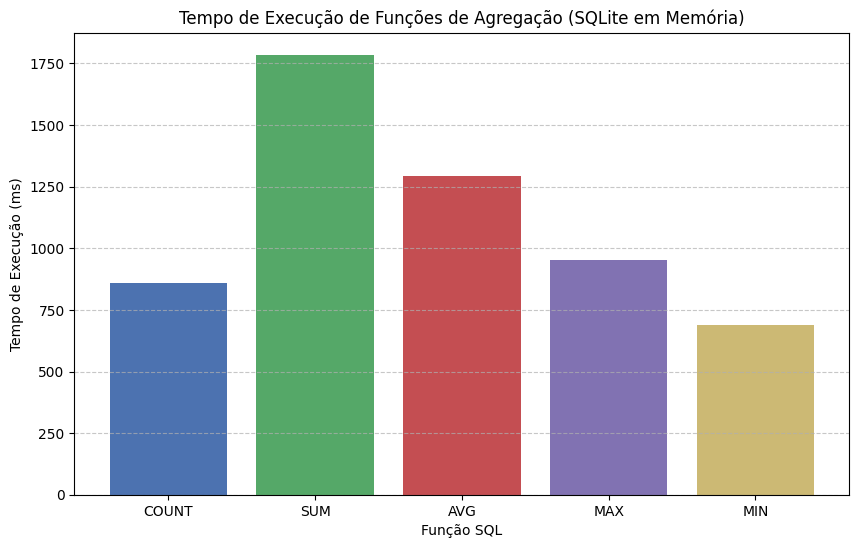


Ciclo concluído. Gráfico exportado como 'grafico.png'.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

def criar_dados_simulados(num_registros=500000):
    """Gera um DataFrame com dados simulados de vendas."""
    np.random.seed(42)
    categorias = ['Eletrônicos', 'Roupas', 'Alimentos', 'Livros', 'Móveis']
    dados = {
        'id': range(1, num_registros + 1),
        'categoria': np.random.choice(categorias, num_registros),
        'valor': np.random.uniform(10.0, 1000.0, num_registros).round(2),
        'quantidade': np.random.randint(1, 20, num_registros)
    }
    return pd.DataFrame(dados)

def configurar_banco(df):
    """Instancia um banco relacional em memória e injeta os dados."""
    conn = sqlite3.connect(':memory:')
    df.to_sql('vendas', conn, index=False, if_exists='replace')
    return conn

def executar_experimento(conn):
    """Executa as funções de agregação e captura as métricas de tempo."""
    queries = {
        'COUNT': "SELECT categoria, COUNT(id) as qtd_vendas FROM vendas GROUP BY categoria",
        'SUM': "SELECT categoria, SUM(valor) as valor_total FROM vendas GROUP BY categoria",
        'AVG': "SELECT categoria, AVG(valor) as valor_medio FROM vendas GROUP BY categoria",
        'MAX': "SELECT categoria, MAX(valor) as valor_maximo FROM vendas GROUP BY categoria",
        'MIN': "SELECT categoria, MIN(valor) as valor_minimo FROM vendas GROUP BY categoria"
    }

    resultados = []

    for nome, query in queries.items():
        inicio = time.time()
        df_res = pd.read_sql_query(query, conn)
        fim = time.time()

        tempo_execucao = (fim - inicio) * 1000  # conversão para milissegundos

        resultados.append({
            'Função de Agregação': nome,
            'Tempo de Execução (ms)': round(tempo_execucao, 4)
        })

    return pd.DataFrame(resultados)

def gerar_grafico(df_resultados):
    """Gera o gráfico comparativo das métricas de desempenho."""
    plt.figure(figsize=(10, 6))
    cores = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
    plt.bar(df_resultados['Função de Agregação'], df_resultados['Tempo de Execução (ms)'], color=cores)

    plt.title('Tempo de Execução de Funções de Agregação (SQLite em Memória)')
    plt.xlabel('Função SQL')
    plt.ylabel('Tempo de Execução (ms)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Salva o gráfico conforme requisito do ciclo de publicação
    plt.savefig('grafico.png')
    plt.show()

def main():
    print("Iniciando o experimento...")
    print("1. Estruturando os dados (Mock Data)...")
    df_vendas = criar_dados_simulados()

    print("2. Inicializando o banco de dados...")
    conn = configurar_banco(df_vendas)

    print("3. Executando e aferindo as consultas de agregação...")
    df_resultados = executar_experimento(conn)

    print("\n--- TABELA DE RESULTADOS FINAIS ---")
    print(df_resultados.to_string(index=False))

    print("\n4. Gerando e exportando os gráficos...")
    gerar_grafico(df_resultados)

    conn.close()
    print("\nCiclo concluído. Gráfico exportado como 'grafico.png'.")

if __name__ == "__main__":
    main()